In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data=pd.read_csv('Housing.csv')

In [ ]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
data.duplicated().sum()

0

In [ ]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

<Axes: >

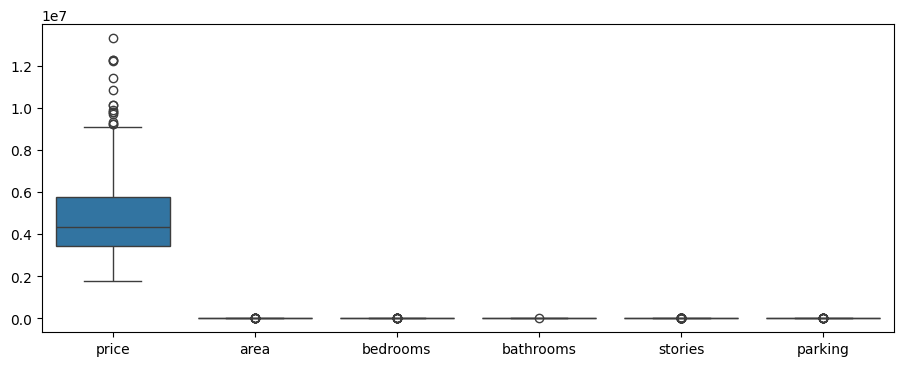

In [ ]:
fig,ax=plt.subplots(figsize=(11,4))
sns.boxplot(data)

In [ ]:
x=data.drop('price',axis=1)
y=data['price']

In [ ]:
x['mainroad']=x['mainroad'].replace(to_replace='yes',value=1)
x['mainroad']=x['mainroad'].replace(to_replace='no',value=0)

x['guestroom']=x['guestroom'].replace(to_replace='yes',value=1)
x['guestroom']=x['guestroom'].replace(to_replace='no',value=0)

x['basement']=x['basement'].replace(to_replace='yes',value=1)
x['basement']=x['basement'].replace(to_replace='no',value=0)

x['hotwaterheating']=x['hotwaterheating'].replace(to_replace='yes',value=1)
x['hotwaterheating']=x['hotwaterheating'].replace(to_replace='no',value=0)

x['airconditioning']=x['airconditioning'].replace(to_replace='yes',value=1)
x['airconditioning']=x['airconditioning'].replace(to_replace='no',value=0)

x['prefarea']=x['prefarea'].replace(to_replace='yes',value=1)
x['prefarea']=x['prefarea'].replace(to_replace='no',value=0)



In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()

In [ ]:
x[['furnishingstatus']]=oe.fit_transform(x[['furnishingstatus']])

In [ ]:
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0.0
1,8960,4,4,4,1,0,0,0,1,3,0,0.0
2,9960,3,2,2,1,0,1,0,0,2,1,1.0
3,7500,4,2,2,1,0,1,0,1,3,1,0.0
4,7420,4,1,2,1,1,1,0,1,2,0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((436, 12), (109, 12), (436,), (109,))

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_test,pred)

0.6654995985480137